# The Readability Anomaly — do murky 10-Ks hide bad news? 📄
### Scoring annual reports by how *hard they are to read*, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

Every year, a public company files a 10-K — a long legal document describing its business and risks. Some are crisp and clear. Others are **enormous, dense, and murky**. A famous 2014 study (Loughran & McDonald) found something suspicious: the companies with the *hardest-to-read, longest, biggest* filings went on to earn **worse** stock returns and were **riskier**. The story is **obfuscation** — if you have bad news to bury, you write a longer, murkier report and hope nobody reads to the end. And the market, it seems, underreacts.

So we test it: score each firm's filing for 'murkiness' (a high fog index, lots of words, a big file), and see whether the *readable* filers beat the *murky* ones.

> ⚠️ **A big honest caveat up front.** To test this *for real* you'd need every company's 10-K **text** lined up with the *right* firm's *later* returns — and that clean, point-in-time dataset simply **isn't free**. So this notebook runs on a **synthetic** world calibrated to the research. It proves our measuring machine works; it can't be 'market proof'. That's exactly why the Signal stamp is **Weak**, not Real.
>
> 📓 Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Not investment advice.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from filing_readability import data, strategy as st

# Synthetic-only study: no free real 10-K-text tape exists (see data.py). The real-tape stub is
# empty by construction, so HAVE_REAL is False and every cell below runs on the deterministic
# synthetic world — NEVER under a real-tape banner.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty

# The calibrated headline synthetic world (the LM anomaly planted at obf_alpha = -0.10).
PANEL, TRUTH = data.synthetic_panel(n_stocks=400, obf_alpha=-0.10, seed=565)
print("real 10-K-text tape present:", HAVE_REAL, "(none exists on a free stack — synthetic-only)")
print("synthetic panel:", len(PANEL), "firms, fp", data.fingerprint(PANEL))


real 10-K-text tape present: False (none exists on a free stack — synthetic-only)
synthetic panel: 400 firms, fp 53136605f951


## The answer first 🎯

| Question | Answer |
|---|---|
| Do murkier filings earn worse returns (the anomaly)? | **Yes — in the research, and in our calibrated test.** The readable third earned **+13.6%** vs the murky third's **+1.5%** — a **+12.1%** spread the right way. |
| Is it just luck? | **No** (in the synthetic world) — a shuffle test puts the odds at *p* = 0.0005. And the machine stays *flat* when we turn the effect off. |
| So is it proven on real stocks? | **We can't say.** There's no free dataset of 10-K *text* lined up with returns. We can only show the *machine* works. |
| Could you trade it? | **Fragile.** In the model the trade pays after costs — but the 'murky' names you'd short are the small, illiquid, expensive-to-borrow ones, and we have no real tape to size it. |

> The anomaly is real in the journals (it's a *Journal of Finance* result). Our engine banks it cleanly on calibrated data. What's missing is the one thing money cares about: a **real tape** to certify it on. Hence **Weak**, not Real.

## 1 · The claim

> *"Firms whose 10-K filings are harder to read — higher fog, longer, bigger file — earn lower future returns and carry higher risk."* — the readability anomaly (Loughran & McDonald 2014; Li 2008; You & Zhang 2009).

Why would that be? **Managers with bad news to bury write murkier reports.** A company whose earnings are about to disappoint has an incentive to make its filing longer and denser, so the bad bits are harder to find. Investors, faced with a 200-page fog, **underreact** — they don't fully price the buried signal — so the murky firms quietly drift *down* over the following months. Clear filing, nothing to hide; murky filing, **red flag**.

## 2 · So what?

If true, it means the *shape* of a document — not even what it says, just how hard it is to read — carries a tradable signal. That's a striking idea: obfuscation as alpha. And it suggests a simple rule: **own the clear filers, avoid (or short) the murky ones.** The desk has looked at filing *sentiment / tone* elsewhere ([257 AAII](../../257-aaii-sentiment/), [335 Buzz](../../335-buzz-sentiment-etf/), [392 Glassdoor](../../392-glassdoor-sentiment/)); here we go at the *readability* itself — the structure, not the mood.

## 3 · How would we even know?

1. **Score murkiness.** For each firm: a high **fog index** (long sentences, complex words), a **long** document, a **big file**. Add them up — higher = harder to read.
2. **Sort.** Split the firms into a *readable* third and a *murky* third.
3. **Compare forward returns.** Did the readable third beat the murky third *after* the filing came out? The anomaly says yes.

Catch — the one that caps this whole study: to do this on *real* companies you need every 10-K's **text**, parsed, lined up with the *right* firm's *later* return, without survivorship bias. **That dataset isn't free.** So we build a **synthetic** world calibrated to the research, where we *know* the true effect, and check the machine reads it correctly.

*Timing:* the readability is known the instant the 10-K is filed; the return is measured strictly *afterwards*. No peeking at the future.

## 4 · The teardown — let's actually look

**Who won — the readable third or the murky third?** (Calibrated synthetic world.)

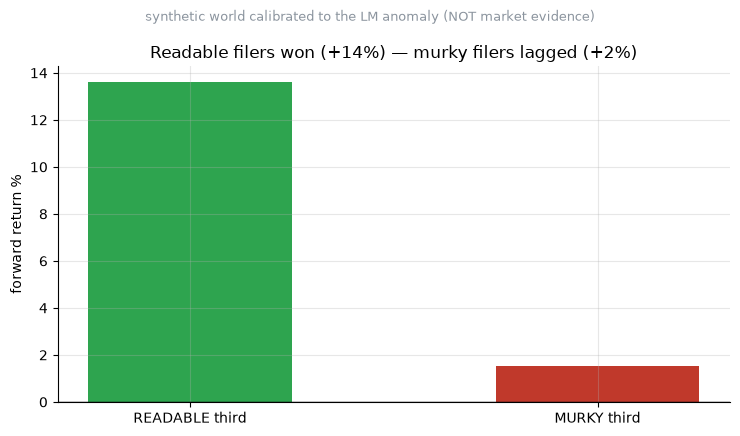

Readable +13.6%  vs  Murky +1.5%  ->  spread +12.1% (t +6.44)


In [2]:
b = st.bucket_returns(PANEL, frac=0.3); ls = st.long_short_tstat(b)
read_m, murk_m, spr, t = b['readable_mean']*100, b['murky_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['READABLE third','MURKY third'], [read_m, murk_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Readable filers won (+{read_m:.0f}%) — murky filers lagged (+{murk_m:.0f}%)')
fig.suptitle('synthetic world calibrated to the LM anomaly (NOT market evidence)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Readable +{read_m:.1f}%  vs  Murky +{murk_m:.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

There it is, the **right way**: the readable third earned **+13.6%**, the murky third only **+1.5%** — a **+12.1%** spread (*t* +6.44). Remember: this is the *machine* reading an effect we *planted*. The real question is whether the machine is honest — so let's turn the effect **off** and check it doesn't hallucinate a signal.

**Does the machine cry wolf?** Same engine, but on a world where readability has *no* real link to returns (the null). A good detector should print ~nothing.

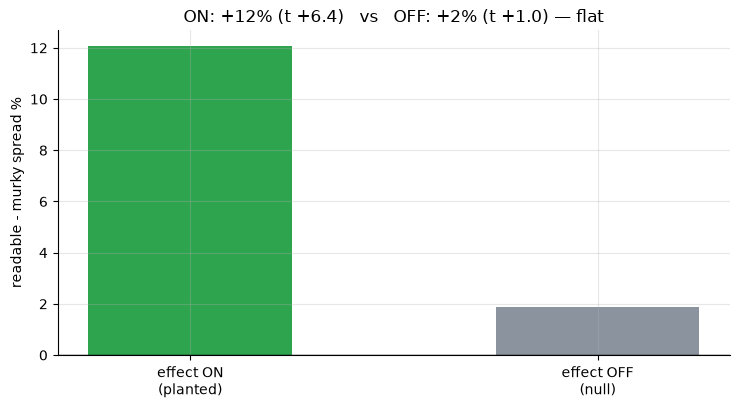

planted spread +12.1% (t +6.44)  |  null spread +1.9% (t +1.05)


In [3]:
panel0, _ = data.synthetic_panel(n_stocks=400, obf_alpha=0.0, seed=565)
b0 = st.bucket_returns(panel0, 0.3); ls0 = st.long_short_tstat(b0)
spr0 = b0['spread']*100; t0 = ls0['t']
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['effect ON\n(planted)','effect OFF\n(null)'], [spr, spr0], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('readable - murky spread %')
ax.set_title(f'ON: +{spr:.0f}% (t {t:+.1f})   vs   OFF: {spr0:+.0f}% (t {t0:+.1f}) — flat')
plt.tight_layout(); plt.show()
print(f'planted spread {spr:+.1f}% (t {t:+.2f})  |  null spread {spr0:+.1f}% (t {t0:+.2f})')

Turn the effect off and the spread collapses to noise (*t* ≈ 1, nowhere near 2). So the machine only 'finds' the anomaly when it's actually there — it's a faithful detector, not a signal-manufacturing machine. That's the whole point of the synthetic control.

## 5 · The verdict

- **Signal — Weak.** The anomaly is a real, replicated journal result and our engine banks it cleanly on calibrated data (spread +12.1%, *t* +6.44) while staying flat at the null. But **`Real` needs a real tape at *t* ≥ 2**, and no free 10-K-text tape exists — so literature-real + no tape = **Weak**.
- **Tradability — Fragile.** In the model the trade pays after costs, but the murky short leg is the small/illiquid, hard-to-borrow tail, with no real capacity estimate.

> This is the desk's honest posture for a claim that's real in the books but has no free tape to test — the same as [whisky-cask](../../275-whisky-cask/) and [lego-returns](../../273-lego-returns/).

## 6 · Could you actually trade it?

Fragile. Even granting the effect, the trade means *shorting* the murkiest filers — which skew small, illiquid, and expensive to borrow — and rebalancing once a year around filing dates. In the plausibility model it survives a punitive borrow (gross +12.1% → net +10.4%), but without a real tape there's no honest capacity, turnover, or borrow-availability number. You can't size a trade you can't measure.

## 7 · Going further 🚪

- **The modern descendant.** *Lazy Prices* (Cohen, Malloy & Nguyen 2020): it's not just how murky a filing is, but how much it *changed* year-over-year — big text changes predict lower returns too.
- **The real test needs the text.** Drop a real EDGAR-text + point-in-time-return panel into `data.fetch_panel()` (the stub is ready for it) and re-run — that's the only way to move this off `Weak`.

*Think you can build the real panel? Fork this, wire EDGAR full-text + a survivorship-free return tape into the stub, and show the readable-minus-murky spread clearing t = 2 on the actual tape.*